# Dynamic Geostrophic Nudging (DGN)

### Manuscript Under Review
**The methodology demonstrated in this repository is associated with the following manuscript, which is currently submitted to *Wind Energy Science*:**

> **Title:** Dynamic Geostrophic Nudging (DGN): A Novel Method for Controlling the Background Flow in Large Eddy Simulation  
> **Authors:** Hai Bui*, Mostafa Bakhoday-Paskyabi, Joachim Reuder  
> **Affiliation:** Geophysical Institute and Bergen Offshore Wind Centre, University of Bergen, Norway.  
> *\*Corresponding author: hai.bui@uib.no*

---

## Overview

Initializing idealized Large-Eddy Simulations (LES) for wind energy and boundary-layer meteorology presents a persistent challenge. Traditional methods of forcing the domain with a constant geostrophic wind ($\mathbf{G}$) result in slow convergence due to the Ekman spiral and severe inertial oscillations. This typically requires 12 to 24 hours of computational spin-up time before the boundary layer reaches a stationary target state.

**Dynamic Geostrophic Nudging (DGN)** is a novel, closed-loop control strategy designed to solve this problem. Instead of applying unphysical Newtonian relaxation directly to the velocity field, DGN acts dynamically on the large-scale forcing parameters (the geostrophic wind components). 

By explicitly incorporating the flow's current tendency and the error from the target velocity, DGN:
1. **Actively damps inertial oscillations**, changing the system response from oscillatory to a pure exponential decay.
2. **Reduces spin-up time** from 12–24 hours to approximately 2 hours.
3. **Automatically discovers the required forcing**, eliminating the need for expensive trial-and-error initialization.
4. **Preserves physical turbulence structures**, as it modifies large-scale forcing without adding artificial source terms to the resolved turbulent eddies.

## Core Formulation

The controller dynamically adjusts the geostrophic wind components ($U_g, V_g$) to achieve a target wind vector ($u_r, v_r$) at a specific reference height. The required updates are calculated as:

$$ \Delta U_g = -\frac{1}{f} \left[ \left(\frac{d\overline{v}}{dt}\right)_{\text{prior}} + \frac{\overline{v} - v_{r}}{\tau} \right] $$

$$ \Delta V_g = \frac{1}{f} \left[ \left(\frac{d\overline{u}}{dt}\right)_{\text{prior}} + \frac{\overline{u} - u_{r}}{\tau} \right] $$

Where $f$ is the Coriolis parameter, $\tau$ is the relaxation timescale, and $\overline{u}, \overline{v}$ are the filtered, horizontally-averaged wind components at the target height. Refer to the associate paper for the complete description of the method.

This repository contains a **Jupyter Notebook** that provides an 1D theoretical demonstration of the DGN method.

For the complete **3D WRF-LES implementation** used in our research, which is built upon the WRF-SADLES framework, please refer to the main manuscript and our official Zenodo archive:
 **[https://doi.org/10.5281/zenodo.19591182](https://doi.org/10.5281/zenodo.19591182)**


## Citation

If you use the DGN method or the associated code in your research, please cite our paper (Update pending publication):

```bibtex
@article{bui202Xdynamic,
  title={Dynamic Geostrophic Nudging (DGN): A Novel Method for Controlling the Background Flow in Large Eddy Simulation},
  author={Bui, Hai and Bakhoday-Paskyabi, Mostafa and Reuder, Joachim},
  journal={Wind Energy Science},
  year={202X},
  note={Submitted}
}
```

## Contact

For questions or bug reports regarding the 1D demonstration, please open an issue in this repository or contact **Hai Bui** at [hai.bui@uib.no](mailto:hai.bui@uib.no).



###  1D model with DGN 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

class EkmanModel1D:
    def __init__(self, params):
        self.params = params
        self.z = np.arange(0, params['z_max'] + params['dz'], params['dz'])
        self.nz = len(self.z)
        self.z_h_idx = np.argmin(np.abs(self.z - params['z_h']))
        self.u = np.full(self.nz, params['u_g_initial'])
        self.v = np.full(self.nz, params['v_g_initial'])
        self.u_g = params['u_g_initial']
        self.v_g = params['v_g_initial']
        self.u[0], self.v[0] = 0, 0
        z_i = self.params.get('z_i', 1000.0)
        self.noise_profile = np.sin(np.pi * self.z / z_i)**2
        self.noise_profile[self.z > z_i] = 0
        # --- NEW: Initialize smoothed state variables ---
        self.u_hub_smooth = self.u[self.z_h_idx]
        self.v_hub_smooth = self.v[self.z_h_idx]
        
    def _calculate_rhs(self, u, v, u_g, v_g):
        f = self.params['f']
        Km = self.params['Km']
        dz = self.params['dz']
        H_nudge = self.params.get('H_nudge', 1000.0)
        T_nudge = self.params.get('T_nudge', 3600.0)
        rhs_u = f * (v - v_g)
        rhs_v = -f * (u - u_g)
        d2u_dz2 = (u[:-2] - 2*u[1:-1] + u[2:]) / dz**2
        d2v_dz2 = (v[:-2] - 2*v[1:-1] + v[2:]) / dz**2
        rhs_u[1:-1] += Km * d2u_dz2
        rhs_v[1:-1] += Km * d2v_dz2
        nudge_mask = self.z > H_nudge
        if np.any(nudge_mask):
            rhs_u[nudge_mask] -= (u[nudge_mask] - u_g) / T_nudge
            rhs_v[nudge_mask] -= (v[nudge_mask] - v_g) / T_nudge
        return rhs_u, rhs_v

    def run(self, t_end, nudge_mode='none', u_ref=10.0, v_ref=0.0, output_filename=None):
        dt = self.params['dt']
        T_filter = self.params.get('T_filter', 300.0)
        tau = self.params.get('tau', 1800.0)
        f = self.params['f']
        noise_amplitude = self.params.get('noise_amplitude', 0.0)
        T_smooth = self.params.get('T_smooth', 1800.0)
        alpha = dt / T_smooth if T_smooth > 0 else 1.0

        times = np.arange(0, t_end + dt, dt)
        nt = len(times)
        output_interval_s = self.params.get('output_interval_s', 300.0)
        output_freq = int(output_interval_s / dt)
        store_indices = np.arange(0, nt, output_freq, dtype=int)
        store_times = times[store_indices]
        u_hist = np.zeros((len(store_times), self.nz))
        v_hist = np.zeros((len(store_times), self.nz))
        u_g_hist = np.zeros(len(store_times))
        v_g_hist = np.zeros(len(store_times))
        time_since_last_update = 0.0
        
        u_hub_smooth_past = self.u_hub_smooth
        v_hub_smooth_past = self.v_hub_smooth
        
        rhs_u, rhs_v = self._calculate_rhs(self.u, self.v, self.u_g, self.v_g)
        store_idx_counter = 0
        for i in range(nt):
            if i in store_indices:
                u_hist[store_idx_counter, :] = self.u
                v_hist[store_idx_counter, :] = self.v
                u_g_hist[store_idx_counter] = self.u_g
                v_g_hist[store_idx_counter] = self.v_g
                store_idx_counter += 1
                
            rhs_u_prev, rhs_v_prev = rhs_u.copy(), rhs_v.copy()
            if i == 0:
                self.u += dt * rhs_u_prev
                self.v += dt * rhs_v_prev
            else:
                self.u += dt * (1.5 * rhs_u - 0.5 * rhs_u_prev)
                self.v += dt * (1.5 * rhs_v - 0.5 * rhs_v_prev)
            if noise_amplitude > 0:
                noise_u_kick = self.noise_profile * noise_amplitude * np.sqrt(dt) * np.random.randn(self.nz)
                noise_v_kick = self.noise_profile * noise_amplitude * np.sqrt(dt) * np.random.randn(self.nz)
                self.u += noise_u_kick
                self.v += noise_v_kick
            
            self.u[0], self.v[0] = 0, 0
            self.u[-1], self.v[-1] = self.u[-2], self.v[-2]
            
            # --- NEW: Update smoothed wind at EVERY timestep ---
            u_hub_raw = self.u[self.z_h_idx]
            v_hub_raw = self.v[self.z_h_idx]
            self.u_hub_smooth = alpha * u_hub_raw + (1 - alpha) * self.u_hub_smooth
            self.v_hub_smooth = alpha * v_hub_raw + (1 - alpha) * self.v_hub_smooth
            
            time_since_last_update += dt
            if nudge_mode != 'none' and time_since_last_update >= T_filter:
                # --- MODIFIED: Controller now ONLY sees the SMOOTHED values ---
                tendency_u_hub = (self.u_hub_smooth - u_hub_smooth_past) / time_since_last_update
                tendency_v_hub = (self.v_hub_smooth - v_hub_smooth_past) / time_since_last_update
                error_term_u = (self.u_hub_smooth - u_ref) / tau
                error_term_v = (self.v_hub_smooth - v_ref) / tau
                
                delta_u_g = -(1.0 / f) * (tendency_v_hub + error_term_v)
                delta_v_g =  (1.0 / f) * (tendency_u_hub + error_term_u)
                self.u_g += delta_u_g
                self.v_g += delta_v_g
                
                time_since_last_update = 0.0
                u_hub_smooth_past = self.u_hub_smooth
                v_hub_smooth_past = self.v_hub_smooth
                
            rhs_u, rhs_v = self._calculate_rhs(self.u, self.v, self.u_g, self.v_g)
            
        dataset = xr.Dataset(
            {
                'u': (('time', 'z'), u_hist),
                'v': (('time', 'z'), v_hist),
                'u_g': (('time',), u_g_hist),
                'v_g': (('time',), v_g_hist),
            },
            coords={
                'time': ('time', store_times / 3600.0),
                'z': ('z', self.z),
            }
        )
        dataset.attrs['description'] = f"1D Ekman Model run with nudge_mode='{nudge_mode}'"
        dataset.attrs.update(self.params)
        if output_filename:
            if os.path.exists(output_filename):
                os.remove(output_filename)
            dataset.to_netcdf(output_filename)
            print(f"Results saved to {output_filename}")
        return dataset
        

# --- HELPER FUNCTIONS  ---
def analytical_ekman(z_profile, G_r, f, Km):
    delta = np.sqrt(2 * Km / f)
    exponent = -(1 + 1j) * z_profile / delta
    v_complex = G_r * (1 - np.exp(exponent))
    return v_complex.real, v_complex.imag

def inverse_ekman(vr_complex, z_h, f, Km):
    delta = np.sqrt(2 * Km / f)
    exponent = -(1 + 1j) * z_h / delta
    G_r_complex = vr_complex / (1 - np.exp(exponent))
    return G_r_complex



## Running experiments

In [24]:
params = {
    'z_max': 1500.0,
    'dz': 20.0,
    'dt': 10.0,
    'f': 1e-4,
    'Km': 1.0,
    'z_h': 100.0,
    'u_g_initial': 10.0,
    'v_g_initial': 0.0,
    'u_ref': 10.0,
    'v_ref': 0.0,
    'tau': 90 * 60,
    'T_filter': 20 * 60,
    'noise_amplitude': 0.01,   # Small noise amplitude
    'z_i': 800.0,
    'H_nudge': 800.0,       # Top nudging layer
    'T_nudge': 3600.0,
    'T_smooth': 300,      # Timescale for EMA filter (30 mins)
    'output_interval_s':60
}

t_end_sim = 24 * 3600

print("\n--- Running Nudging Case ---")
model = EkmanModel1D(params)
res = model.run(
    t_end=t_end_sim, 
    nudge_mode='approximate',
    output_filename="Nudge.nc"
)


print("\n--- Running NoNudging Case  ---")
model = EkmanModel1D(params)
res = model.run(
    t_end=t_end_sim, 
    nudge_mode='none',
    output_filename="NoNudge.nc"
)




--- Running Nudging Case ---
Results saved to Nudge.nc

--- Running NoNudging Case  ---
Results saved to NoNudge.nc


## Plotting results

{'label': 'NoNudge', 'file': 'NoNudge.nc'}
10.0 0.0
{'label': 'Nudge', 'file': 'Nudge.nc'}
12.5981504373622 -6.517484680740419


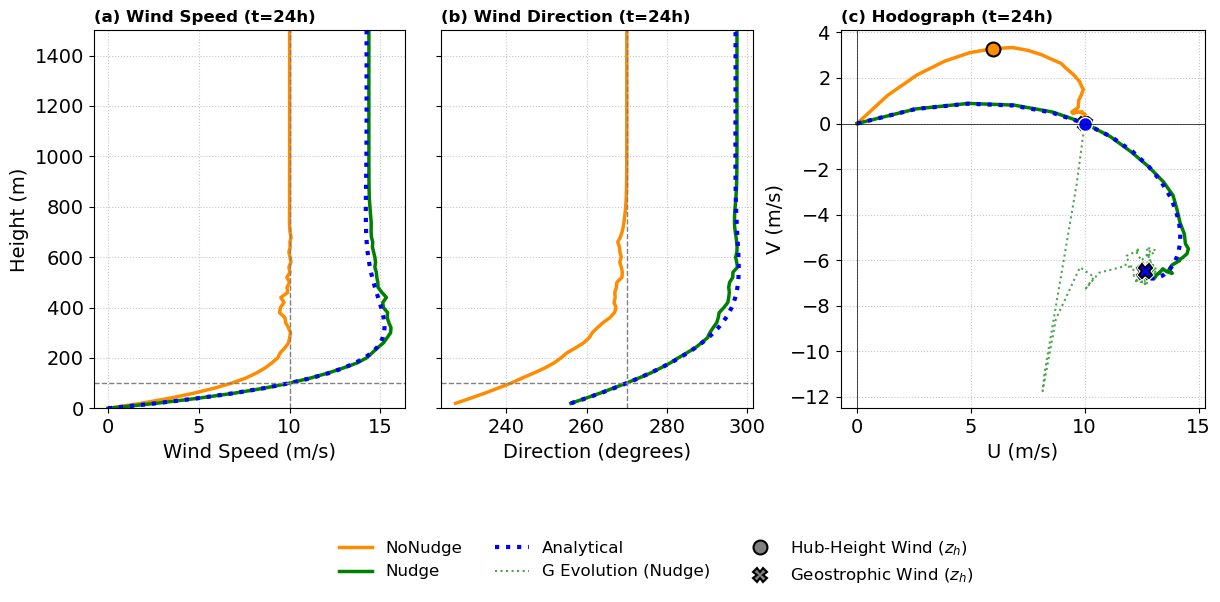

In [25]:
STYLES = {
    'NoNudge': {
        'profile': {'color': 'darkorange', 'linestyle': '-', 'linewidth': 2.5},
        'hub_marker': {'marker': 'o', 'markerfacecolor': 'darkorange', 'markeredgecolor': 'black', 'markersize': 10, 'mew': 1.5},
        'g_marker': {
            'marker': 'X', 'markerfacecolor': 'darkorange', 'markeredgecolor': 'black','markersize': 10, 'markeredgewidth': 1.5,
            'path_effects': [pe.Stroke(linewidth=3, foreground='white'), pe.Normal()]
        }        
    },
    'Nudge': {
        'profile': {'color': 'green', 'linestyle': '-', 'linewidth': 2.5},
        'hub_marker': {'marker': 'o', 'markerfacecolor': 'green', 'markeredgecolor': 'black', 'markersize': 9, 'mew': 1.5},
        'g_evolution': {'color': 'green', 'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.7},
        'g_marker': {
            'marker': 'X', 'markerfacecolor': 'green', 'markeredgecolor': 'black','markersize': 10, 'markeredgewidth': 1.5,
            'path_effects': [pe.Stroke(linewidth=3, foreground='white'), pe.Normal()]
        }        
    },
    'Analytical': {
        'profile': {'color': 'blue', 'linestyle': ':', 'linewidth': 3.0},
        'hub_marker': {'marker': 'o', 'markerfacecolor': 'blue', 'markeredgecolor': 'white', 'markersize': 10},
        'g_marker': {
            'marker': 'X', 'markerfacecolor': 'blue', 'markeredgecolor': 'black','markersize': 10, 'markeredgewidth': 1.5,
            'path_effects': [pe.Stroke(linewidth=3, foreground='white'), pe.Normal()]
        }
    },
    'TargetLines': {
        'color': 'gray', 'linestyle': '--', 'linewidth': 1.0
    }
}
FONT_SIZES = {
    'label': 14,
    'tick': 14,
    'title': 16,
    'legend': 12
}



# --- DATA AND FIGURE SETUP ---
cases = [
    {'label': 'NoNudge', 'file': 'NoNudge.nc'},
    {'label': 'Nudge', 'file': 'Nudge.nc'}
]
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1, 1.5]})
legend_handles = {}

# --- 4. DATA LOADING AND CALCULATION ---
ds_nonudge = xr.open_dataset('NoNudge.nc')
# --- MODIFICATION: Use the instantaneous final state for G_r calculation ---
final_state_nonudge = ds_nonudge.isel(time=-1)

f_param = ds_nonudge.attrs.get('f', 1e-4)
Km_param = ds_nonudge.attrs.get('Km', 1.0)
z_h = ds_nonudge.attrs['z_h']
z = final_state_nonudge['z'].values
z_h_idx = np.argmin(np.abs(z - z_h))
G0_complex = complex(ds_nonudge.attrs['u_g_initial'], ds_nonudge.attrs['v_g_initial'])
vr_complex = complex(ds_nonudge.attrs['u_ref'], ds_nonudge.attrs['v_ref'])
v_tilde_complex = complex(final_state_nonudge['u'][z_h_idx].item(), final_state_nonudge['v'][z_h_idx].item())
Gr_analytical_complex = inverse_ekman(vr_complex, z_h, f_param, Km_param)
u_ref_val = ds_nonudge.attrs['u_ref']
v_ref_val = ds_nonudge.attrs['v_ref']
target_dir_val = 270 - np.rad2deg(np.arctan2(v_ref_val, u_ref_val))

# --- 5. MAIN PLOTTING LOGIC ---
for case in cases:
    ds = xr.open_dataset(case['file'])
    # --- MODIFICATION: Use the instantaneous final state for profiles ---
    final_state = ds.isel(time=-1)
    
    u_final, v_final = final_state['u'].values, final_state['v'].values
    ws_final = np.sqrt(u_final**2 + v_final**2)
    wd_final = 270 - np.rad2deg(np.arctan2(v_final, u_final)); wd_final[ws_final < 0.1] = np.nan
    
    style_key = case['label']
    line, = axes[0].plot(ws_final, z, label=style_key, **STYLES[style_key]['profile'])
    legend_handles[style_key] = line
    axes[1].plot(wd_final, z, **STYLES[style_key]['profile'])
    axes[2].plot(u_final, v_final, **STYLES[style_key]['profile'])
    axes[2].plot(u_final[z_h_idx], v_final[z_h_idx], **STYLES[style_key]['hub_marker'])

    u_g_hist, v_g_hist = ds['u_g'].values, ds['v_g'].values
    if 'g_evolution' in STYLES[style_key]:        
        axes[2].plot(u_g_hist, v_g_hist, **STYLES[style_key]['g_evolution'])

    print(case)
    print(u_g_hist[-1], v_g_hist[-1])
    axes[2].plot(u_g_hist[-1], v_g_hist[-1], **STYLES[style_key]['g_marker'])


# --- Plot Analytical Solution (Unchanged) ---
u_ekman, v_ekman = analytical_ekman(z, Gr_analytical_complex, f_param, Km_param)
ws_ekman = np.sqrt(u_ekman**2 + v_ekman**2); wd_ekman = 270 - np.rad2deg(np.arctan2(v_ekman, u_ekman)); wd_ekman[ws_ekman < 0.1] = np.nan
line, = axes[0].plot(ws_ekman, z, label='Analytical', **STYLES['Analytical']['profile']); legend_handles['Analytical Ekman'] = line
axes[1].plot(wd_ekman, z, **STYLES['Analytical']['profile'])
axes[2].plot(u_ekman, v_ekman, **STYLES['Analytical']['profile'])
axes[2].plot(u_ekman[z_h_idx], v_ekman[z_h_idx], **STYLES['Analytical']['hub_marker'])
axes[2].plot(Gr_analytical_complex.real, Gr_analytical_complex.imag, **STYLES['Analytical']['g_marker'])

# --- 6. FINAL FORMATTING (Updated Titles) ---
axes[0].set_title('(a) Wind Speed (t=24h)', fontweight='bold', loc="left"); axes[0].set_xlabel('Wind Speed (m/s)'); axes[0].set_ylabel('Height (m)')
axes[1].set_title('(b) Wind Direction (t=24h)', fontweight='bold', loc="left"); axes[1].set_xlabel('Direction (degrees)'); axes[1].set_yticklabels([])
axes[2].set_title('(c) Hodograph (t=24h)', fontweight='bold', loc="left"); axes[2].set_xlabel('U (m/s)'); axes[2].set_ylabel('V (m/s)')

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZES['tick'])
    ax.xaxis.label.set_size(FONT_SIZES['label']); ax.yaxis.label.set_size(FONT_SIZES['label']); ax.title.set_size(FONT_SIZES['title'])
for ax in [axes[0], axes[1]]: ax.axhline(z_h, **STYLES['TargetLines']); ax.set_ylim(0, z.max())
axes[0].axvline(u_ref_val, **STYLES['TargetLines']); axes[1].axvline(target_dir_val, **STYLES['TargetLines'])
axes[2].axhline(0, color='black', lw=0.5); axes[2].axvline(0, color='black', lw=0.5); axes[2].set_aspect('equal', 'box')


# --- 7. LEGEND CREATION ---
hub_marker = Line2D([],[], color='gray', marker='o', linestyle='None', markersize=10, markeredgecolor='black', mew=1.5, label='Hub-Height Wind ($z_h$)')
g_marker = Line2D([],[], color='gray', marker='X', linestyle='None', markersize=10, markeredgecolor='black', mew=1.5, label='Geostrophic Wind ($z_h$)')

g_evolution_line = Line2D([],[], **STYLES['Nudge']['g_evolution'], label='G Evolution (Nudge)')

final_legend_handles = [legend_handles['NoNudge'], legend_handles['Nudge'], legend_handles['Analytical Ekman'],
                        g_evolution_line, hub_marker, g_marker]
final_legend_labels = [h.get_label() for h in final_legend_handles]

fig.legend(final_legend_handles, final_legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=3, fontsize=FONT_SIZES['legend'], frameon=False)
plt.subplots_adjust(bottom=0.25, wspace=0.1)

plt.savefig("DGN_1D_comparison.png")

plt.show()